# ReKIS resampling

In [1]:
import matplotlib.pyplot as plt
import xarray
import rasterio

In [2]:
PATH = '/rci_data/climate/ReKIS/KlimRefDS_v3.1_1961-2023/Raster/Tag/GK4/'

Y = xarray.open_mfdataset(PATH + "TM/*.nc", decode_coords="all")
Y = Y["TM"]
Y = Y.sel({'time' : '2000-02-01'})
Y = Y.isel(easting=slice(0, 400), northing=slice(0, 400))
Y.rio.set_spatial_dims("easting", "northing")

<xarray.DataArray 'TM' (northing: 400, easting: 400)> Size: 640kB
dask.array<getitem, shape=(400, 400), dtype=float32, chunksize=(134, 140), chunktype=numpy.ndarray>
Coordinates:
  * easting   (easting) float64 3kB 4.336e+06 4.336e+06 ... 4.734e+06 4.734e+06
  * northing  (northing) float64 3kB 5.954e+06 5.954e+06 ... 5.556e+06 5.556e+06
    time      datetime64[ns] 8B 2000-02-01
    crs       int32 4B -2147483647
Attributes:
    units:      °C
    long_name:  mittlere Temperatur

Different resampling methods ...

In [3]:
resamplings = {
    'nearest' : rasterio.enums.Resampling.nearest,
    'bilinear' : rasterio.enums.Resampling.bilinear,
    'cubic' : rasterio.enums.Resampling.cubic,
    'cubic spline' : rasterio.enums.Resampling.cubic_spline,
    'Lanczos' : rasterio.enums.Resampling.lanczos,
    'average' : rasterio.enums.Resampling.average
}

... applied on the same image

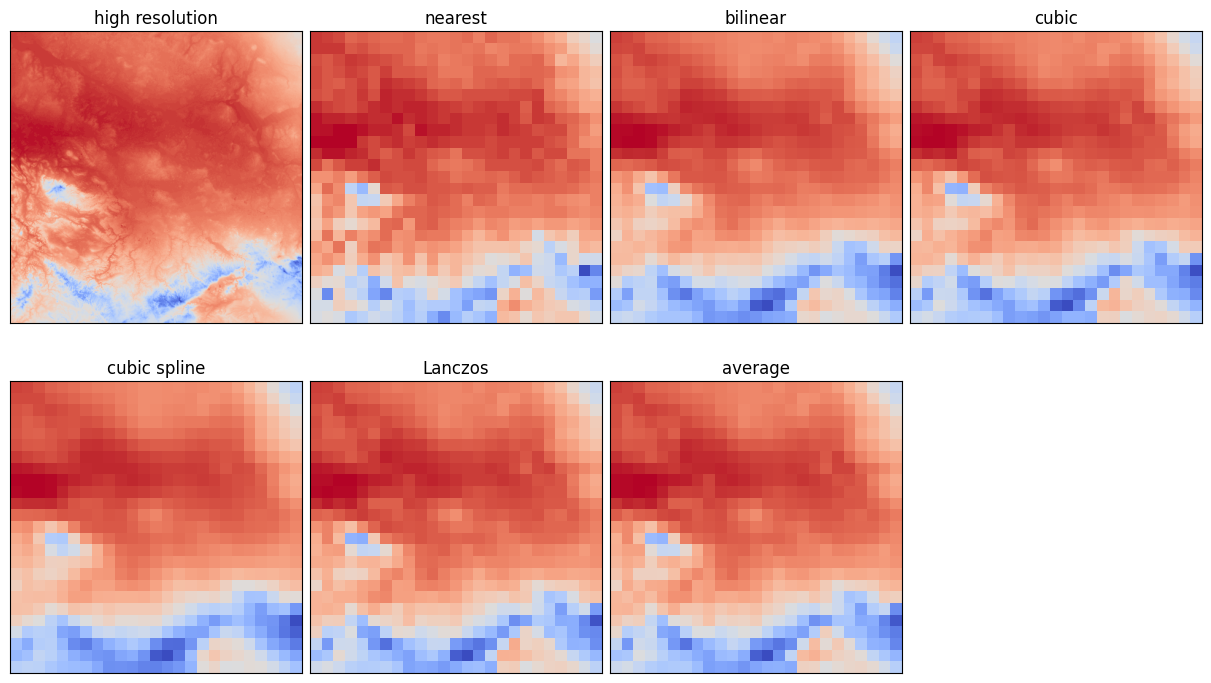

In [4]:
fig, axes = plt.subplots(ncols=4, nrows=2, constrained_layout=True, figsize=(12, 7))

axes[0, 0].set_title("high resolution")
axes[0, 0].imshow(Y.squeeze(), cmap="coolwarm")
axes[0, 0].xaxis.set_visible(False)
axes[0, 0].yaxis.set_visible(False)

i = 1
for resampling_name, resampling in resamplings.items():
    X = Y.rio.reproject(Y.rio.crs, resolution=(16_000, 16_000), resampling=resampling)
    axes[i // 4, i % 4].imshow(X.squeeze(), cmap="coolwarm")
    axes[i // 4, i % 4].set_title(resampling_name)
    axes[i // 4, i % 4].xaxis.set_visible(False)
    axes[i // 4, i % 4].yaxis.set_visible(False)
    i += 1

axes[1, 3].set_visible(False)
plt.show()

fig.savefig('images/resampling.pdf', bbox_inches='tight', dpi=300)